# Laboratório de Dados — Simulação de Decisões de Crédito por Algoritmo

**Projeto Integrador de IA e Governança — Parte 3**

Este notebook simula o ambiente de trabalho de um cientista de dados que precisa **carregar, explorar e auditar** uma base de dados usada por um algoritmo de concessão de crédito, verificando se há sinais de viés (por exemplo, diferenças de aprovação entre regiões ou faixas de renda).

**Passo 1 — Faça upload do arquivo `dados_creditos_simulados.csv` no Colab** (ícone de pasta à esquerda → upload) antes de rodar a célula abaixo.

In [26]:
# Importa a biblioteca pandas, usada para manipulação de dados tabulares
import pandas as pd

# Lê o arquivo CSV simulado e carrega em um DataFrame
# (o arquivo deve estar na mesma pasta do notebook no Colab)
df = pd.read_csv('dados_creditos_simulados.csv')

# Mostra as 5 primeiras linhas para conferir se a leitura funcionou
df.head()

,id_solicitante,idade,renda_mensal,tempo_emprego_anos,score_credito,regiao,decisao_algoritmo
0,1001,22,1800,1,510,Norte,Negado
1,1002,35,4200,8,690,Sudeste,Aprovado
2,1003,29,2600,3,560,Nordeste,Negado
3,1004,41,7800,15,740,Sul,Aprovado
4,1005,26,2100,2,530,Norte,Negado


\# Passo 2 — Inspeção geral da base

In [27]:
# Informações gerais: tipos de dados e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id_solicitante      20 non-null     int64 
 1   idade               20 non-null     int64 
 2   renda_mensal        20 non-null     int64 
 3   tempo_emprego_anos  20 non-null     int64 
 4   score_credito       20 non-null     int64 
 5   regiao              20 non-null     object
 6   decisao_algoritmo   20 non-null     object
dtypes: int64(5), object(2)
memory usage: 1.2+ KB


In [28]:
# Estatísticas descritivas das colunas numéricas
# (média, desvio padrão, mínimo, máximo etc.)
df.describe()

,id_solicitante,idade,renda_mensal,tempo_emprego_anos,score_credito
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,1010.50000,34.400000,4497.500000,8.700000,625.500000
std,5.91608,9.708379,2840.611267,8.291403,104.590681
min,1001.00000,22.000000,1600.000000,1.000000,490.000000
25%,1005.75000,26.750000,2175.000000,2.000000,527.500000
50%,1010.50000,32.000000,3350.000000,5.500000,620.000000
75%,1015.25000,41.250000,6875.000000,15.250000,716.250000
max,1020.00000,55.000000,10500.000000,28.000000,800.000000


## Passo 3 — Auditoria simples de viés por região

Aqui verificamos se a **taxa de aprovação** do algoritmo é parecida entre as regiões, o que ajuda a identificar possíveis disparidades — o mesmo tipo de checagem discutida no relatório da Parte 1.

In [29]:
# Cria uma coluna auxiliar: 1 se aprovado, 0 se negado
df['aprovado_num'] = (df['decisao_algoritmo'] == 'Aprovado').astype(int)

# Calcula a taxa de aprovação por região
taxa_aprovacao_regiao = df.groupby('regiao')['aprovado_num'].mean().sort_values(ascending=False)

print('Taxa de aprovação por região:')
print((taxa_aprovacao_regiao * 100).round(1).astype(str) + '%')

Taxa de aprovação por região:
regiao
Sul             100.0%
Sudeste         100.0%
Centro-Oeste     66.7%
Norte             0.0%
Nordeste          0.0%
Name: aprovado_num, dtype: object


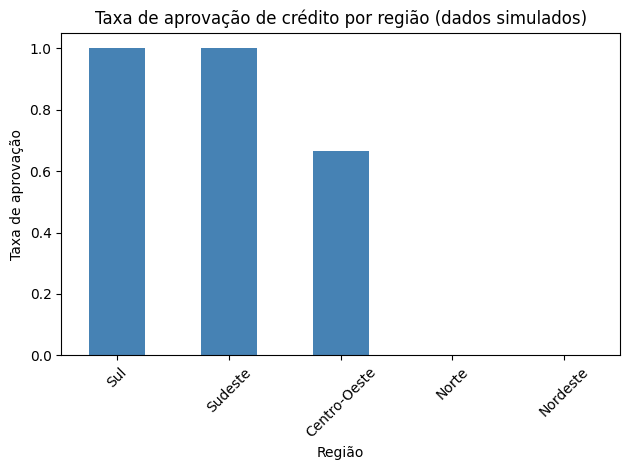

In [30]:
import matplotlib.pyplot as plt

# Gráfico de barras simples comparando a taxa de aprovação entre regiões
taxa_aprovacao_regiao.plot(kind='bar', color='steelblue')
plt.title('Taxa de aprovação de crédito por região (dados simulados)')
plt.ylabel('Taxa de aprovação')
plt.xlabel('Região')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Passo 4 — Renda média por decisão

Compara a renda mensal média entre solicitantes aprovados e negados, outro indicador simples para discutir critérios de exclusão financeira.

In [31]:
renda_media_por_decisao = df.groupby('decisao_algoritmo')['renda_mensal'].mean().round(2)
print('Renda mensal média por decisão do algoritmo:')
print(renda_media_por_decisao)

Renda mensal média por decisão do algoritmo:
decisao_algoritmo
Aprovado    6436.36
Negado      2127.78
Name: renda_mensal, dtype: float64


## Conclusão

Mesmo em uma base simulada e pequena, é possível perceber diferenças na taxa de aprovação entre grupos (aqui, regiões). Em um cenário real, esse tipo de análise exploratória é o primeiro passo de uma **auditoria de viés algorítmico**, conectando o trabalho técnico do cientista de dados às discussões de governança e regulamentação feitas na Parte 1 deste projeto.

**Próximos passos sugeridos para a equipe:** salvar este notebook no Google Colab (Arquivo → Salvar uma cópia no Drive), ativar o compartilhamento por link e colar o link no relatório final e no README do GitHub.